So we are going to try and model the count data. Using the following framework.

$$
a_1^t = \log(\text{age\_0\_4}+1)\\
a_2^t = \log(\text{age\_5\_24}+1)\\
a_{3,0}^t = \log(\text{age\_25\_64}+1)\\
a_{3,1}^t = \log(\text{age\_25\_49}+1)\\
a_{3,2}^t = \log(\text{age\_50\_64}+1)\\
a_4^t = \log(\text{age\_65}+1)\\
a_5^t = \log(\text{num\_of\_providers}+1)\\
a_6^t = \log(\text{non\_ilitotal}+1)\\
$$

$$\begin{pmatrix}
\lambda_1^t\\
\lambda_2^t\\
\lambda_3^t\\
\lambda_4^t\\
\lambda_5^t\\
\lambda_6^t\\
\end{pmatrix} 
=


$$

Now due to the nature of this problem we will need to difference at 19 as well as 1 year so for any variable it would come out looking something like.
$$(1-B)(1-B^{19})(1-B^{52})a_i^t =  (1-B)(1-B^{19})(1-B^{52})e_i^t$$

In [44]:
# install.packages("smooth")
# library(smooth)
fdf <- read.csv("data/fluview_clean/ilinet_final.csv")
model <- msarima(fdf$age_0_4, orders=list(ar=c(1,1,1), i=c(1,1,1), ma=c(1,1,1)), 
                 lags=c(1, 19, 52))
prop_model <- auto.msarima(fdf$age_0_4, lags=c(1, 19,33,42,47, 52))

sqrt(mean(residuals(model)^2))
sqrt(mean(residuals(prop_model)^2))
prop_model

[1] 0.5907656

[1] 0.3834781

Time elapsed: 3.26 seconds
Model estimated using auto.adam() function: SARIMA(2,1,0)[1](0,0,1)[19]
With backcasting initialisation
Distribution assumed in the model: Normal
Loss function type: likelihood; Loss function value: 682.4102
ARMA parameters of the model:
       Lag 1
AR(1) 0.0274
AR(2) 0.0462
       Lag 19
MA(1) -0.6143

Sample size: 1482
Number of estimated parameters: 4
Number of degrees of freedom: 1478
Information criteria:
     AIC     AICc      BIC     BICc 
1372.820 1372.848 1394.025 1394.124 

In [ ]:
# 1-step-ahead rolling forecast RMSE for msarima (+ in-sample RMSE + log-likelihood)
library(smooth)

fdf <- read.csv("data/fluview_clean/ilinet_final.csv")
y <- as.numeric(fdf$age_0_4)



# Evaluate on the last h points using rolling-origin 1-step forecasts
h <- 104
n <- length(y)
stopifnot(h < n)

test_idx <- (n - h + 1):n
pred <- rep(NA_real_, h)
sse <- 0

for (i in seq_along(test_idx)) {
  t_idx <- test_idx[i]
  train_i <- y[1:(t_idx - 1)]
  
  fit_i <- msarima(
    train_i,
    orders = list(ar=c(1,0,1), i=c(1,1,0), ma=c(1,0,1)),
        lags = c(1, 52, 19)
  )
  
  fc_i <- forecast(fit_i, h = 1)
  pred_i <- if (!is.null(fc_i$mean)) {
    as.numeric(fc_i$mean[1])
  } else if (!is.null(fc_i$forecast)) {
    as.numeric(fc_i$forecast[1])
  } else {
    as.numeric(fc_i)[1]
  }
  
  pred[i] <- pred_i
  err_i <- y[t_idx] - pred_i
  sse <- sse + err_i^2
}

# Rolling 1-step out-of-sample RMSE
rmse_roll_1step <- sqrt(sse / h)

# In-sample RMSE on the training block used for evaluation
train0 <- y[1:(n - h)]
fit_train0 <- msarima(
  train0,
  orders = list(ar = c(1, 1,1), i = c(1, 1,1), ma = c(1, 1,1)),
  lags = c(1, 19, 52)
)
res_train0 <- tryCatch(as.numeric(residuals(fit_train0)),
                       error = function(e) as.numeric(fit_train0$errors))
rmse_insample <- sqrt(mean(res_train0^2, na.rm = TRUE))




cat("Rolling 1-step test RMSE:", rmse_roll_1step, "\n")
cat("In-sample train RMSE:", rmse_insample, "\n")
cat("Train-model log-likelihood:", fit_train0$logLik, "\n")

Rolling 1-step test RMSE: 0.1232181 
In-sample train RMSE: 0.5094652 
Train-model log-likelihood: -1025.983 


And we get a muchhhh lower RMSE than my group did woahhhhhh what do you know...


So now we want to do this in multiple dimensions and then we are going to calculate the expectation of the variables.
We will then see if we can infer back from this the actual values of the data.

In [46]:
# Rolling 1-step-ahead RMSE for auto.msarima
library(smooth)

fdf <- read.csv("data/fluview_clean/ilinet_final.csv")
y <- as.numeric(fdf$age_0_4)

h <- 104
n <- length(y)
stopifnot(h < n)

test_idx <- (n - h + 1):n
pred <- rep(NA_real_, h)

for (i in seq_along(test_idx)) {
  t_idx <- test_idx[i]
  train_i <- y[1:(t_idx - 1)]

  fit_i <- auto.msarima(
    train_i,
    lags = c(1, 19, 52)
  )

  fc_i <- forecast(fit_i, h = 1)
  pred[i] <- if (!is.null(fc_i$mean)) {
    as.numeric(fc_i$mean[1])
  } else if (!is.null(fc_i$forecast)) {
    as.numeric(fc_i$forecast[1])
  } else {
    as.numeric(fc_i)[1]
  }
}

test <- y[test_idx]
rmse_roll_1step <- sqrt(mean((test - pred)^2, na.rm = TRUE))

fit_full <- auto.msarima(y, lags = c(1, 19, 52))
fit_train <- auto.msarima(y[1:(n - h)], lags = c(1, 19, 52))

res_train <- tryCatch(
  as.numeric(residuals(fit_train)),
  error = function(e) as.numeric(fit_train$errors)
 )
rmse_insample <- sqrt(mean(res_train^2, na.rm = TRUE))

cat("Rolling 1-step auto.msarima RMSE:", rmse_roll_1step, "\n")
cat("In-sample auto.msarima RMSE:", rmse_insample, "\n")
cat("Train log-likelihood:", fit_train$logLik, "\n")
cat("Full-sample log-likelihood:", fit_full$logLik, "\n")
fit_full

Rolling 1-step auto.msarima RMSE: 0.1212034 
In-sample auto.msarima RMSE: 0.396856 
Train log-likelihood: -681.7747 
Full-sample log-likelihood: -682.4102 


Time elapsed: 3.38 seconds
Model estimated using auto.adam() function: SARIMA(2,1,0)[1](0,0,1)[19]
With backcasting initialisation
Distribution assumed in the model: Normal
Loss function type: likelihood; Loss function value: 682.4102
ARMA parameters of the model:
       Lag 1
AR(1) 0.0274
AR(2) 0.0462
       Lag 19
MA(1) -0.6143

Sample size: 1482
Number of estimated parameters: 4
Number of degrees of freedom: 1478
Information criteria:
     AIC     AICc      BIC     BICc 
1372.820 1372.848 1394.025 1394.124 

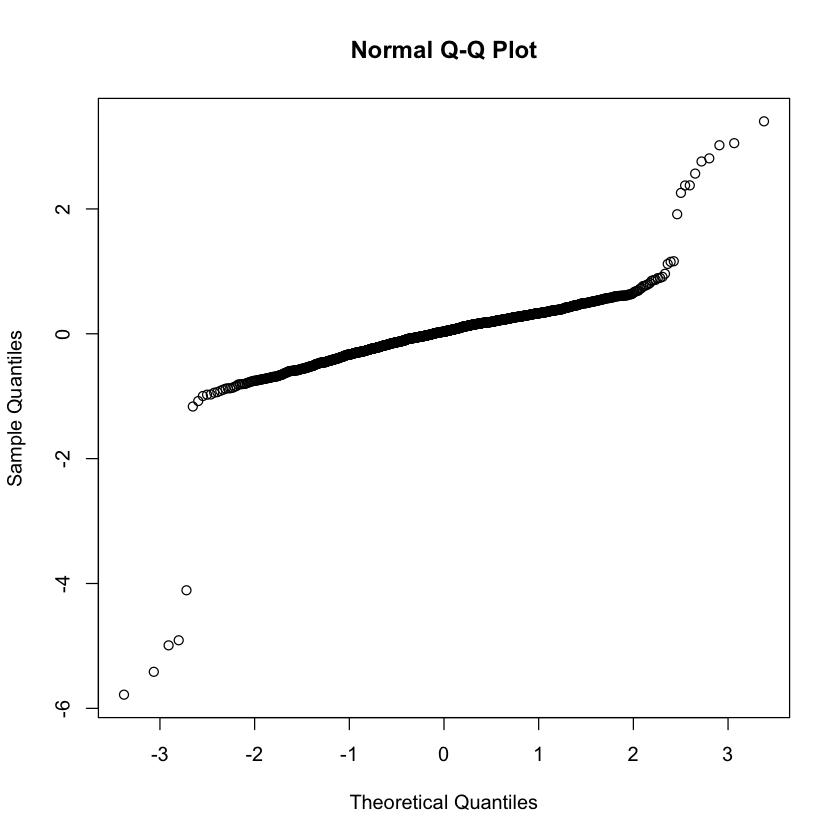

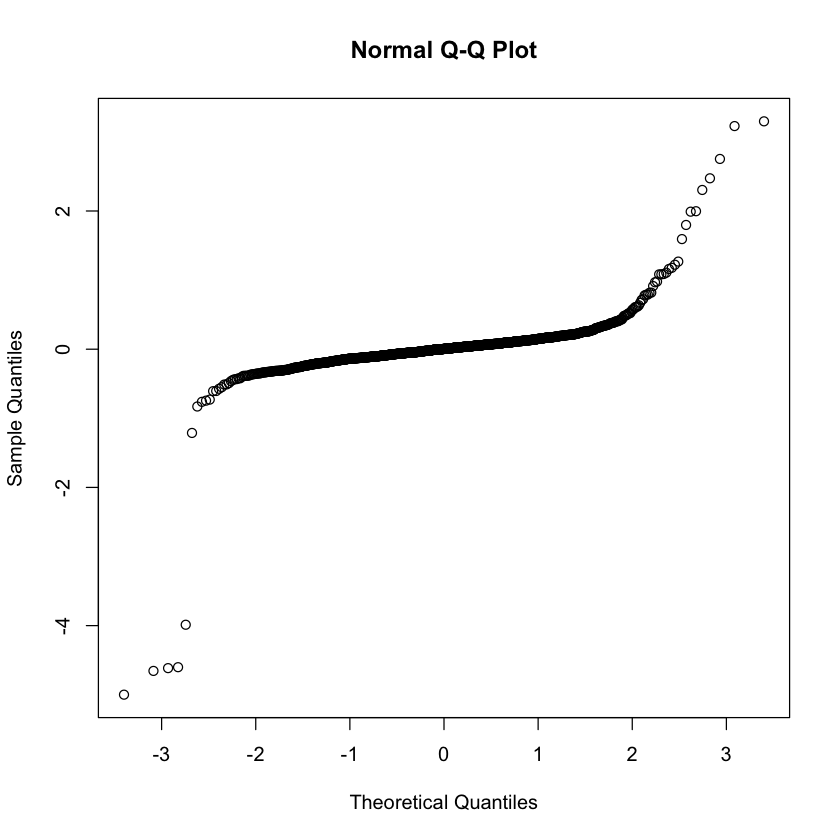

In [50]:
qqnorm(residuals(fit_train0))
qqnorm(residuals(fit_full))

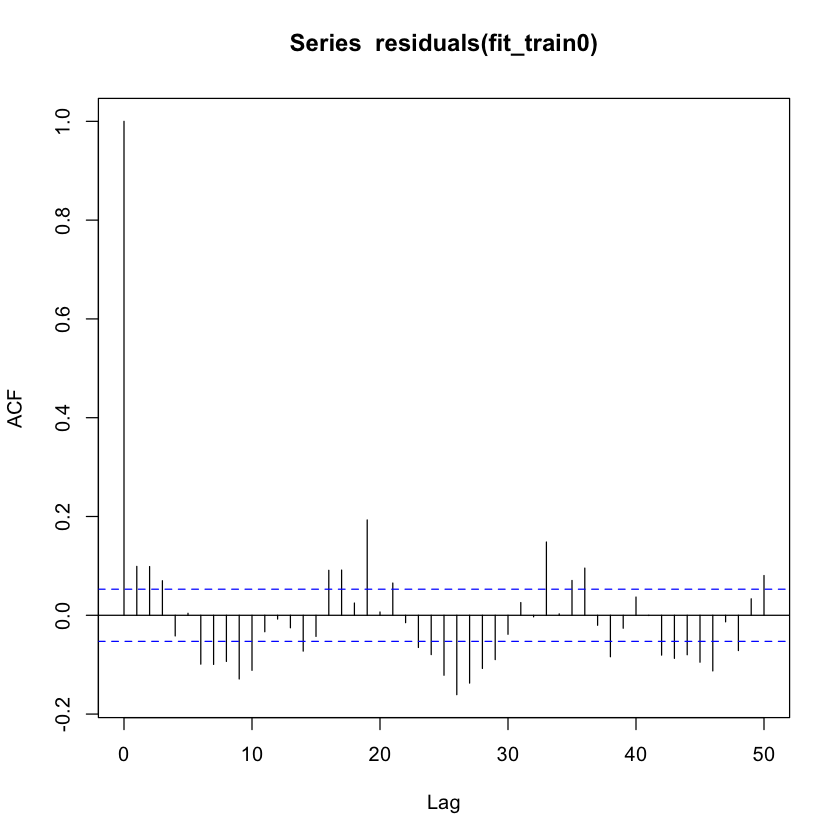

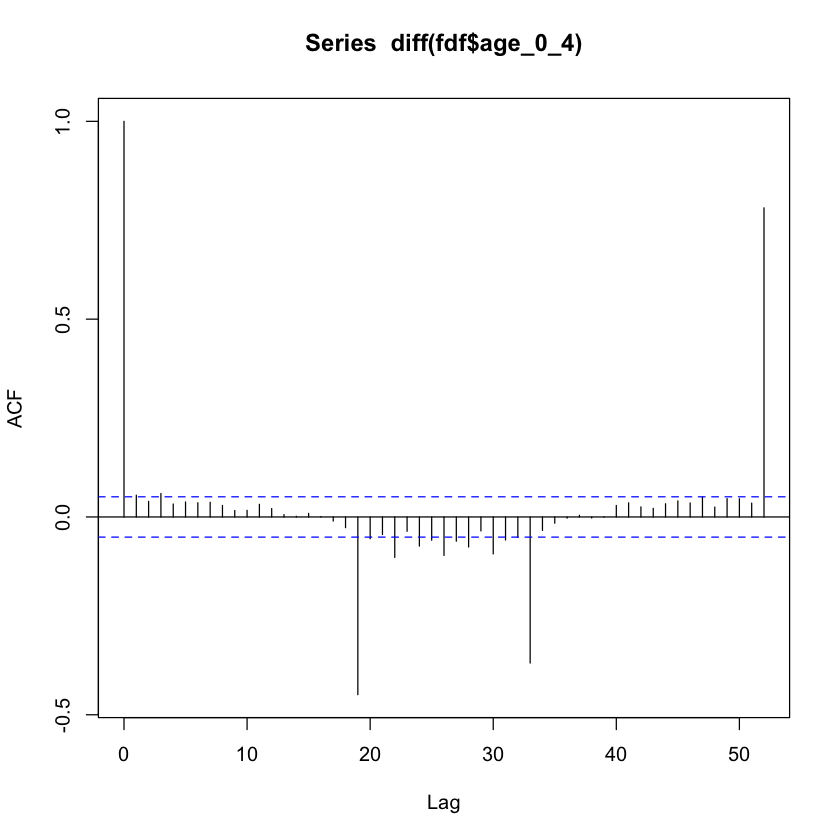

In [54]:
acf(residuals(fit_train0), lag.max = 50)
acf(diff(fdf$age_0_4), lag.max = 52)

In [55]:
fit_train0 <- msarima(
  train0,
  orders = list(ar = c(1,1,1,1), i = c(1,1,1,1), ma = c(1,1,1,1)),
  lags = c(1, 19, 33, 52)
)

In-sample RMSE for extended model: 1.054634 


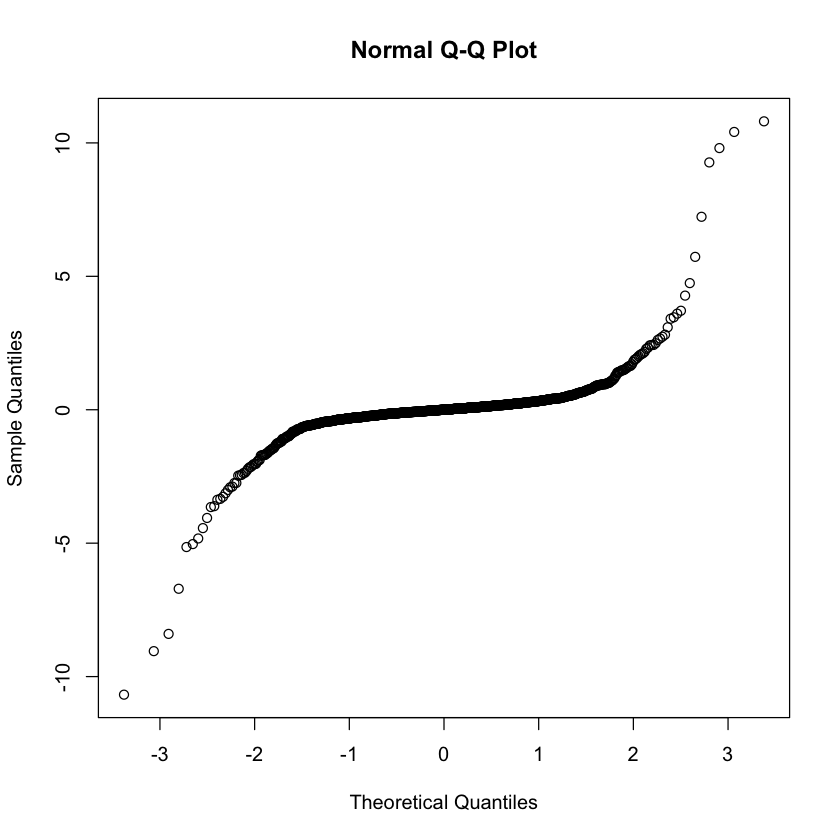

In [62]:
# qqplot(residuals(fit_train0))
rmse_insample <- sqrt(mean(residuals(fit_train0)^2, na.rm = TRUE))
cat("In-sample RMSE for extended model:", rmse_insample, "\n")
qqnorm(residuals(fit_train0))

In [ ]:
# we want to find the min and max of the ili
df <- read.csv("data/fluview_clean/ilinet_clean.csv")  

data <- df$percent_weighted_ili
# we now want to find the min and max over the testing period
test_period <- (nrow(df) - 103):nrow(df)  # Last 104 points are test
test_data <- data[test_period]
min_ili <- min(test_data, na.rm = TRUE)
max_ili <- max(test_data, na.rm = TRUE)
# train_period <- 1:(nrow(df) - 104)  # Assuming last 104 points are test



[1] 0.02981873